In [ ]:
!pip install -q emoji scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re, emoji, os
from sklearn.model_selection import train_test_split

# =====================
# 1. LOAD FILE
# =====================
input_file = "/content/goemotions_1.csv"   # <<< change to your filename
df = pd.read_csv(input_file)

print("Loaded:", df.shape)


# =====================
# 2. PREPROCESS TEXT
# =====================
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"[^a-z0-9\s!?,.]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["text"] = df["text"].apply(preprocess)


# =====================
# 3. DEFINE LABELS
# =====================

GO_LABELS = [
 "admiration","amusement","anger","annoyance","approval","caring","confusion","curiosity",
 "desire","disappointment","disapproval","disgust","embarrassment","excitement","fear",
 "gratitude","grief","joy","love","nervousness","optimism","pride","realization",
 "relief","remorse","sadness","surprise","neutral"
]

EKMAN_LABELS = ["joy", "sadness", "anger", "fear", "surprise", "disgust"]

EKMAN_MAP = {
    "joy": {"amusement","excitement","joy","optimism","relief","admiration","love","approval","pride"},
    "sadness": {"sadness","grief","disappointment","remorse"},
    "anger": {"anger","annoyance"},
    "fear": {"fear","nervousness"},
    "surprise": {"surprise","realization"},
    "disgust": {"disgust","embarrassment"}
}

# convert GoEmotion row → Ekman row
def go_to_ekman(row):
    # Assumes emotion labels are directly column names in the DataFrame
    go_names = [label for label in GO_LABELS if label in row.index and row[label] == 1]

    ek = {e: 0 for e in EKMAN_LABELS}

    for emotion in EKMAN_LABELS:
        if EKMAN_MAP[emotion].intersection(set(go_names)):
            ek[emotion] = 1

    return pd.Series(ek)

# FIX STARTS HERE
# Create a DataFrame containing only the Ekman labels for each row
ekman_labels_only_df = df.apply(go_to_ekman, axis=1)

# Concatenate the 'text' column from the original df with the new Ekman labels DataFrame.
# This avoids column name collisions from the original GO_LABELS that overlap with EKMAN_LABELS.
ekman_df = pd.concat([df['text'], ekman_labels_only_df], axis=1)

# Remove neutral-only rows
ekman_df = ekman_df[ekman_df[EKMAN_LABELS].sum(axis=1) > 0]
# FIX ENDS HERE

print("After mapping:", ekman_df.shape)


# =====================
# 4. PAPER TARGET COUNTS
# =====================

PAPER_COUNTS = {
    "joy":     {"train": 9189, "val": 1314, "test": 1834},
    "sadness": {"train": 6217, "val": 888,  "test": 1287},
    "anger":   {"train": 5093, "val": 728,  "test": 998},
    "fear":    {"train": 5261, "val": 752,  "test": 1064},
    "surprise":{"train": 4142, "val": 592,  "test": 871},
    "disgust": {"train": 687,  "val": 98,   "test": 151}
}

train_rows = []
val_rows = []
test_rows = []


# =====================
# 5. BALANCING AND SPLITTING
# =====================
for emo in EKMAN_LABELS:
    emo_df = ekman_df[ekman_df[emo] == 1]

    required_train = PAPER_COUNTS[emo]["train"]
    required_val = PAPER_COUNTS[emo]["val"]
    required_test = PAPER_COUNTS[emo]["test"]

    print(f"\nEmotion {emo}: found={len(emo_df)} required={required_train + required_val + required_test}")

    if len(emo_df) < (required_train + required_val + required_test):
        print(f"WARNING: Not enough samples for {emo}. Using max available = {len(emo_df)}")
        emo_df = emo_df.sample(len(emo_df), random_state=42)
    else:
        emo_df = emo_df.sample(required_train + required_val + required_test, random_state=42)

    # Split train (70%) / temp (30%) first
    emo_train, emo_temp = train_test_split(
        emo_df, test_size=(required_val + required_test) / (required_train + required_val + required_test),
        random_state=42
    )

    # Split temp equally into val & test
    emo_val, emo_test = train_test_split(
        emo_temp, test_size=required_test / (required_val + required_test),
        random_state=42
    )

    train_rows.append(emo_train)
    val_rows.append(emo_val)
    test_rows.append(emo_test)


# =====================
# 6. CONCAT ALL EMOTIONS
# =====================
train_df = pd.concat(train_rows).sample(frac=1, random_state=42)
val_df = pd.concat(val_rows).sample(frac=1, random_state=42)
test_df = pd.concat(test_rows).sample(frac=1, random_state=42)

print("\nFinal dataset sizes:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


# =====================
# 7. SAVE FILES
# =====================
os.makedirs("balanced_output", exist_ok=True)

train_df.to_csv("balanced_output/train.csv", index=False)
val_df.to_csv("balanced_output/val.csv", index=False)
test_df.to_csv("balanced_output/test.csv", index=False)

print("\nSaved to folder: balanced_output/")

Loaded: (70000, 37)
After mapping: (39380, 7)

Emotion joy: found=22512 required=12337

Emotion sadness: found=5573 required=8392

Emotion anger: found=6588 required=6819

Emotion fear: found=1490 required=7077

Emotion surprise: found=4574 required=5605

Emotion disgust: found=2459 required=936

Final dataset sizes:
Train: (23411, 7)
Val: (3345, 7)
Test: (4742, 7)

Saved to folder: balanced_output/


In [ ]:
import pandas as pd
import numpy as np
import re, emoji, pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving goemotions_1.csv to goemotions_1 (1).csv


,text,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
def preprocess(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"[^a-z0-9\s!?.,]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


In [ ]:
GO_LABELS = [
 "admiration","amusement","anger","annoyance","approval","caring","confusion","curiosity",
 "desire","disappointment","disapproval","disgust","embarrassment","excitement","fear",
 "gratitude","grief","joy","love","nervousness","optimism","pride","realization",
 "relief","remorse","sadness","surprise","neutral"
]

EKMAN_LABELS = ["joy","sadness","anger","fear","surprise","disgust"]
np.save("ekman_labels.npy", EKMAN_LABELS)

EKMAN_MAP = {
    "joy": {"amusement","excitement","joy","optimism","relief","admiration","love","approval","pride"},
    "sadness": {"sadness","grief","disappointment","remorse"},
    "anger": {"anger","annoyance"},
    "fear": {"fear","nervousness"},
    "surprise": {"surprise","realization"},
    "disgust": {"disgust","embarrassment"}
}

def go_to_ekman(go_names):
    ek = np.zeros(len(EKMAN_LABELS), dtype=int)
    for i, e in enumerate(EKMAN_LABELS):
        if EKMAN_MAP[e].intersection(set(go_names)):
            ek[i] = 1
    return ek


In [ ]:
texts = []
targets = []

for i, row in df.iterrows():
    text = preprocess(row["text"])

    # FIX STARTS HERE
    # Directly use GO_LABELS as column names, as seen in df.head()
    go_names = [label for label in GO_LABELS if row[label] == 1]
    # FIX ENDS HERE

    ek = go_to_ekman(go_names)

    # Skip neutral → paper removes neutral
    if ek.sum() == 0:
        continue

    texts.append(text)
    targets.append(ek)

X_texts = np.array(texts)
y = np.array(targets)

print("Total filtered samples:", len(X_texts))


Total filtered samples: 39380


In [ ]:
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(X_texts)

seqs = tokenizer.texts_to_sequences(X_texts)
X = pad_sequences(seqs, maxlen=MAX_LEN)

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [ ]:
# Step 1: Split train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

# Step 2: Split temp into val (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (27566, 100)
Val: (5907, 100)
Test: (5907, 100)


In [ ]:
pos = y_train.sum(axis=0)
n = y_train.shape[0]
class_weights = (n - pos) / (pos + 1e-9)

np.save("class_weights.npy", class_weights)


In [ ]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class CapsuleLayer(Layer):
    def __init__(self, num_capsule, dim_capsule, routings=3, **kwargs):
        super().__init__(**kwargs)
        self.num_capsule = num_capsule
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.input_num_capsule = input_shape[1]
        self.input_dim_capsule = input_shape[2]
        self.W = self.add_weight(
            shape=[self.input_num_capsule, self.num_capsule,
                   self.input_dim_capsule, self.dim_capsule],
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        inputs_expand = K.expand_dims(inputs, 2)
        inputs_tiled = K.tile(inputs_expand, [1, 1, self.num_capsule, 1])
        u_hat = K.map_fn(lambda x: K.batch_dot(x, self.W, [2, 2]), elems=inputs_tiled)

        b = K.zeros_like(u_hat[..., 0])
        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=2)
            c_exp = K.expand_dims(c, -1)
            s = K.sum(c_exp * u_hat, axis=1)
            v = self.squash(s)
            if i < self.routings - 1:
                b += K.sum(u_hat * K.expand_dims(v, 1), axis=-1)
        return v

    def squash(self, s, axis=-1):
        s_norm = K.sum(K.square(s), axis, keepdims=True)
        return (s_norm / (1 + s_norm)) * s / (K.sqrt(s_norm + K.epsilon()))


In [ ]:
def build_model():
    inp = layers.Input(shape=(MAX_LEN,))
    x = layers.Embedding(MAX_WORDS, 200)(inp)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)

    att = layers.MultiHeadAttention(num_heads=8, key_dim=32)(x, x)

    merged = layers.Concatenate()([x, att])
    proj = layers.TimeDistributed(layers.Dense(64, activation="relu"))(merged)

    caps = CapsuleLayer(num_capsule=6, dim_capsule=16, routings=3)(proj)

    flat = layers.Flatten()(caps)
    out = layers.Dense(6, activation="sigmoid")(flat)
    return models.Model(inp, out)

model = build_model()
model.summary()


Instructions for updating:
Use fn_output_signature instead


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 200)  │  4,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 256)  │    336,896 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 256)  │    263,168 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 512)  │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 100, 64)   │     32,832 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capsule_layer       │ (None, 6, 6, 16)  │    614,400 │ time_distributed… │
│ (CapsuleLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 576)       │          0 │ capsule_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │      3,462 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,250,758 (20.03 MB)

 Trainable params: 5,250,758 (20.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cw = tf.constant(class_weights, dtype=tf.float32)

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce = -(y_true * tf.math.log(y_pred) +
            (1 - y_true) * tf.math.log(1 - y_pred))
    return tf.reduce_mean(bce * cw)


In [ ]:
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=weighted_bce,
    metrics=["accuracy"]
)

ckpt = callbacks.ModelCheckpoint(
    "best_text_model.h5",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[ckpt]
)


Epoch 1/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5649 - loss: 2.8395

431/431 ━━━━━━━━━━━━━━━━━━━━ 62s 113ms/step - accuracy: 0.5649 - loss: 2.8391 - val_accuracy: 0.5705 - val_loss: 2.6048
Epoch 2/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5774 - loss: 2.5422

431/431 ━━━━━━━━━━━━━━━━━━━━ 78s 117ms/step - accuracy: 0.5774 - loss: 2.5419 - val_accuracy: 0.5971 - val_loss: 2.2937
Epoch 3/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6064 - loss: 2.1694

431/431 ━━━━━━━━━━━━━━━━━━━━ 54s 126ms/step - accuracy: 0.6064 - loss: 2.1693 - val_accuracy: 0.6072 - val_loss: 2.2348
Epoch 4/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - accuracy: 0.6370 - loss: 1.9146 - val_accuracy: 0.6132 - val_loss: 2.2481
Epoch 5/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 47s 110ms/step - accuracy: 0.6556 - loss: 1.7617 - val_accuracy: 0.6017 - val_loss: 2.3512
Epoch 6/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 50s 116ms/step - accuracy: 0.6852 - loss: 1.5806 - val_accuracy: 0.5996 - val_loss: 2.3909
Epoch 7/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 46s 107ms/step - accuracy: 0.7187 - loss: 1.4035 - val_accuracy: 0.5725 - val_loss: 2.4645
Epoch 8/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.7486 - loss: 1.2456 - val_accuracy: 0.5907 - val_loss: 2.6061
Epoch 9/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.7680 - loss: 1.1005 - val_accuracy: 0.6018 - val_loss: 2.6169
Epoch 10/20
431/431 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.7816 - loss: 1.0181 - va

In [ ]:
pred_test = model.predict(X_test)

th = 0.35
pred_bin = (pred_test >= th).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, pred_bin, average='macro', zero_division=0
)

print("Macro-F1:", f1)
print("Precision:", prec)
print("Recall:", rec)


185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
Macro-F1: 0.42708818840951346
Precision: 0.43566276408617827
Recall: 0.4236361870180074


In [ ]:
best = tf.keras.models.load_model("best_text_model.h5",
                                  custom_objects={"CapsuleLayer": CapsuleLayer,
                                                  "weighted_bce": weighted_bce})

def predict_emotion(text):
    t = preprocess(text)
    seq = tokenizer.texts_to_sequences([t])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    pred = best.predict(pad)[0]
    return dict(zip(EKMAN_LABELS, pred))

predict_emotion("got tired bcoz of presentation")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


{'joy': np.float32(0.17278609),
 'sadness': np.float32(0.36517385),
 'anger': np.float32(0.24555734),
 'fear': np.float32(0.044201933),
 'surprise': np.float32(0.18499538),
 'disgust': np.float32(0.13033362)}

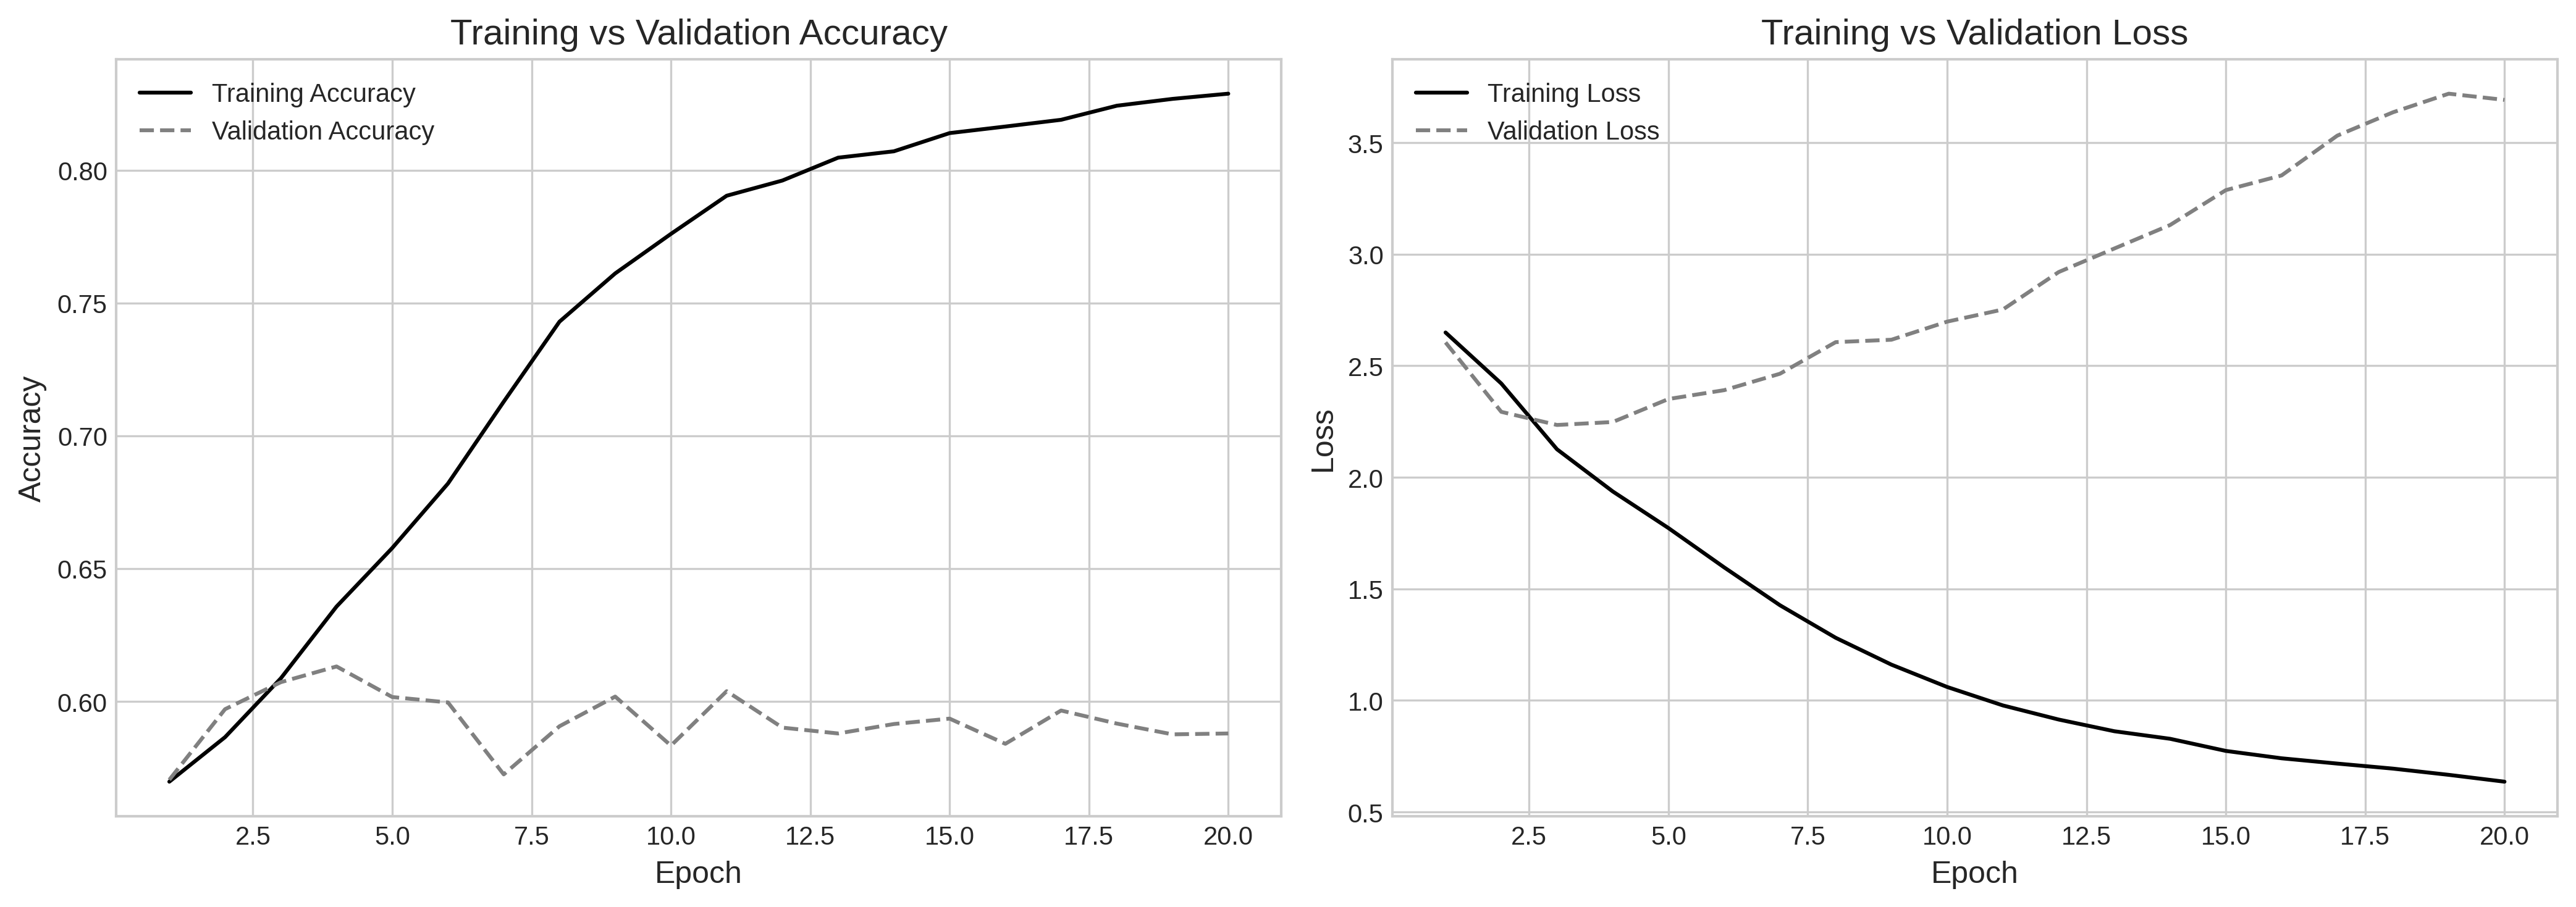

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# High DPI for publication
plt.figure(figsize=(14, 5), dpi=300)

# Data
epochs = range(1, len(history.history['accuracy']) + 1)
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

# ------------------- ACCURACY PLOT -------------------
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy', color='black', linewidth=1.5)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='gray', linestyle='--', linewidth=1.5)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()

# ------------------- LOSS PLOT -------------------
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss', color='black', linewidth=1.5)
plt.plot(epochs, val_loss, label='Validation Loss', color='gray', linestyle='--', linewidth=1.5)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss", fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()

# Save as vector graphic (best for IEEE)
plt.savefig("training_metrics.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()
